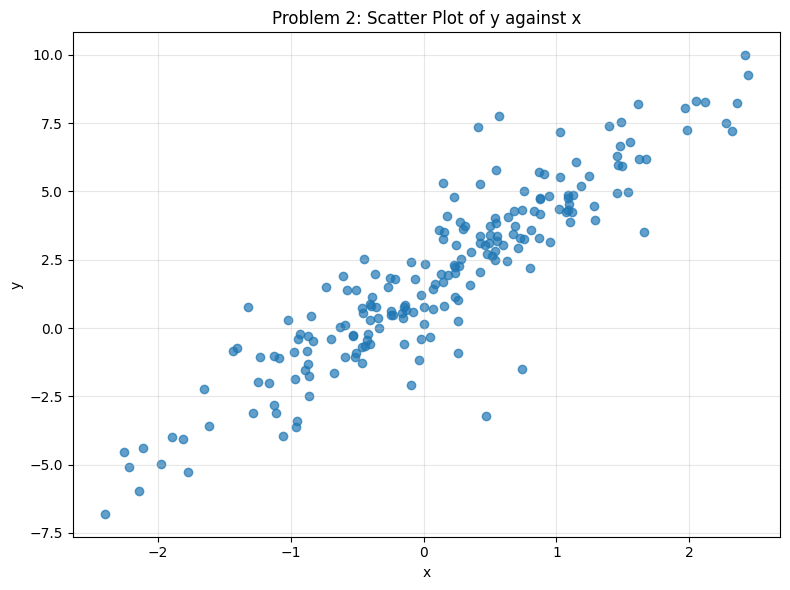

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

# --------------------------------------------------
# Problem 2: Load data
# --------------------------------------------------

data = pd.read_csv("problem2.csv")

# Extract variables
x = data["x"]
y = data["y"]

# --------------------------------------------------
# Predict step: plot y against x BEFORE fitting
# --------------------------------------------------

plt.figure(figsize=(8, 6))

plt.scatter(x, y, alpha=0.7)

plt.xlabel("x")
plt.ylabel("y")
plt.title("Problem 2: Scatter Plot of y against x")

plt.grid(alpha=0.3)
plt.tight_layout()

plt.show()

In [ ]:
import pandas as pd
import numpy as np
from scipy.optimize import minimize
from scipy.stats import norm, t


# Problem 2: Load data

data = pd.read_csv("problem2.csv")

x = data["x"].to_numpy()
y = data["y"].to_numpy()

n = len(y)

# Add a column of ones for the intercept:
# y = alpha + beta*x + error
# X @ [alpha, beta]' gives the fitted y values.
X = np.column_stack((np.ones(n), x))

# Number of regression coefficients:
# alpha and beta
p = X.shape[1]


# ==================================================
# 1. Ordinary Least Squares
# ==================================================

# OLS minimizes the sum of squared residuals:
#
#     sum(error_i^2)
#
# Closed-form solution:
#
#     beta_hat = (X'X)^(-1) X'y

ols_coef = np.linalg.inv(X.T @ X) @ X.T @ y

alpha_ols = ols_coef[0]
beta_ols = ols_coef[1]

# Fitted values and residuals
y_hat_ols = X @ ols_coef
resid_ols = y - y_hat_ols

# Sum of squared errors
SSE = np.sum(resid_ols**2)

# Unbiased estimator of residual variance.
# We estimated p = 2 regression parameters,
# so the denominator is n - p.
s2_ols = SSE / (n - p)
s_ols = np.sqrt(s2_ols)

# Variance-covariance matrix of OLS coefficients:
#
# Var(beta_hat | X) = s^2 (X'X)^(-1)

var_coef_ols = s2_ols * np.linalg.inv(X.T @ X)

# Standard errors are the square roots of
# the diagonal elements.
se_ols = np.sqrt(np.diag(var_coef_ols))

se_alpha_ols = se_ols[0]
se_beta_ols = se_ols[1]


# ==================================================
# 2. Maximum Likelihood with Normal Errors
# ==================================================
#
# Model:
#
# y_i = alpha + beta*x_i + epsilon_i
#
# epsilon_i ~ Normal(0, sigma^2)
#
# The Normal MLE for alpha and beta is identical
# to OLS. The difference is the variance convention:
#
# sigma_MLE^2 = SSE / n
#
# rather than SSE / (n - p).

alpha_normal = alpha_ols
beta_normal = beta_ols

sigma2_normal = SSE / n
sigma_normal = np.sqrt(sigma2_normal)

resid_normal = y - (alpha_normal + beta_normal * x)

# Log likelihood evaluated at the fitted parameters
loglik_normal = np.sum(
    norm.logpdf(
        resid_normal,
        loc=0,
        scale=sigma_normal
    )
)

# Normal regression fits:
# alpha, beta, sigma
#
# Therefore k = 3.
k_normal = 3

AIC_normal = 2 * k_normal - 2 * loglik_normal

AICc_normal = (
    AIC_normal
    + (2 * k_normal**2 + 2 * k_normal)
    / (n - k_normal - 1)
)


# ==================================================
# 3. Maximum Likelihood with Student's t Errors
# ==================================================
#
# Model:
#
# epsilon_i ~ t_nu(0, scale)
#
# Parameters:
# alpha = intercept
# beta  = slope
# nu    = degrees of freedom
# scale = Student-t scale parameter


def negative_log_likelihood_t(params):
    """
    Negative log likelihood for regression with
    Student's t distributed errors.

    params:
        alpha
        beta
        log_scale
        log_nu_minus_2

    Transformations are used so that:
        scale > 0
        nu > 2

    nu > 2 guarantees finite variance.
    """

    alpha = params[0]
    beta = params[1]

    # Exponential transformation forces scale > 0
    scale = np.exp(params[2])

    # Force nu > 2 so the fitted t distribution
    # has finite variance.
    nu = 2 + np.exp(params[3])

    residuals = y - (alpha + beta * x)

    log_likelihood = np.sum(
        t.logpdf(
            residuals,
            df=nu,
            loc=0,
            scale=scale
        )
    )

    # scipy.optimize.minimize minimizes,
    # so return negative log likelihood.
    return -log_likelihood


# --------------------------------------------------
# Starting values
# --------------------------------------------------
#
# OLS provides sensible starting values for alpha
# and beta.
#
# Use the OLS residual scale as the initial scale.
# Start nu around 5, which represents visibly
# heavier tails than a Normal distribution.

initial_params = np.array([
    alpha_ols,
    beta_ols,
    np.log(s_ols),
    np.log(5 - 2)
])


# --------------------------------------------------
# Numerical optimization
# --------------------------------------------------

t_result = minimize(
    negative_log_likelihood_t,
    initial_params,
    method="BFGS"
)

if not t_result.success:
    print("Warning: Student-t optimizer message:")
    print(t_result.message)


# Recover fitted parameters
alpha_t = t_result.x[0]
beta_t = t_result.x[1]

scale_t = np.exp(t_result.x[2])
nu_t = 2 + np.exp(t_result.x[3])

# Maximum log likelihood
loglik_t = -t_result.fun

# Student-t regression fits:
# alpha, beta, scale, nu
#
# Therefore k = 4.
k_t = 4

AIC_t = 2 * k_t - 2 * loglik_t

AICc_t = (
    AIC_t
    + (2 * k_t**2 + 2 * k_t)
    / (n - k_t - 1)
)


# ==================================================
# Print Results
# ==================================================

print("\n========================================")
print("Problem 2 - Regression Model Fits")
print("========================================")


# --------------------------------------------------
# OLS
# --------------------------------------------------

print("\n1. OLS")
print("----------------------------------------")
print(f"alpha:                 {alpha_ols:.6f}")
print(f"beta:                  {beta_ols:.6f}")
print(f"SE(alpha):             {se_alpha_ols:.6f}")
print(f"SE(beta):              {se_beta_ols:.6f}")
print(f"Residual std. error:   {s_ols:.6f}")


# --------------------------------------------------
# Normal MLE
# --------------------------------------------------

print("\n2. Normal-error MLE")
print("----------------------------------------")
print(f"alpha:                 {alpha_normal:.6f}")
print(f"beta:                  {beta_normal:.6f}")
print(f"sigma:                 {sigma_normal:.6f}")
print(f"Log likelihood:        {loglik_normal:.6f}")
print(f"AICc:                  {AICc_normal:.6f}")


# --------------------------------------------------
# Student-t MLE
# --------------------------------------------------

print("\n3. Student-t-error MLE")
print("----------------------------------------")
print(f"alpha:                 {alpha_t:.6f}")
print(f"beta:                  {beta_t:.6f}")
print(f"scale:                 {scale_t:.6f}")
print(f"degrees of freedom nu: {nu_t:.6f}")
print(f"Log likelihood:        {loglik_t:.6f}")
print(f"AICc:                  {AICc_t:.6f}")


# --------------------------------------------------
# Model comparison
# --------------------------------------------------

print("\n4. AICc Comparison")
print("----------------------------------------")
print(f"Normal AICc:           {AICc_normal:.6f}")
print(f"Student-t AICc:        {AICc_t:.6f}")

if AICc_t < AICc_normal:
    print("Preferred model:       Student-t")
else:
    print("Preferred model:       Normal")

print(
    f"AICc difference:        "
    f"{abs(AICc_normal - AICc_t):.6f}"
)


Problem 2 - Regression Model Fits

1. OLS
----------------------------------------
alpha:                 1.560740
beta:                  2.990757
SE(alpha):             0.096269
SE(beta):              0.096640
Residual std. error:   1.351401

2. Normal-error MLE
----------------------------------------
alpha:                 1.560740
beta:                  2.990757
sigma:                 1.344627
Log likelihood:        -343.011037
AICc:                  692.144523

3. Student-t-error MLE
----------------------------------------
alpha:                 1.547979
beta:                  3.019179
scale:                 0.935509
degrees of freedom nu: 3.632166
Log likelihood:        -328.561179
AICc:                  665.327487

4. AICc Comparison
----------------------------------------
Normal AICc:           692.144523
Student-t AICc:        665.327487
Preferred model:       Student-t
AICc difference:        26.817036


In [3]:
# ==================================================
# 5. Compare 95% and 99.5% Error Quantiles
# ==================================================

# Normal:
#     epsilon ~ Normal(0, sigma_normal^2)
#
# Student-t:
#     epsilon ~ t_nu(0, scale_t)


# --------------------------------------------------
# Normal-error quantiles
# --------------------------------------------------

normal_q95 = norm.ppf(
    0.95,
    loc=0,
    scale=sigma_normal
)

normal_q995 = norm.ppf(
    0.995,
    loc=0,
    scale=sigma_normal
)


# --------------------------------------------------
# Student-t-error quantiles
# --------------------------------------------------

t_q95 = t.ppf(
    0.95,
    df=nu_t,
    loc=0,
    scale=scale_t
)

t_q995 = t.ppf(
    0.995,
    df=nu_t,
    loc=0,
    scale=scale_t
)


# --------------------------------------------------
# Print quantile comparison
# --------------------------------------------------

print("\n5. Error Quantile Comparison")
print("----------------------------------------")

print("Normal-error model:")
print(f"95% quantile:           {normal_q95:.6f}")
print(f"99.5% quantile:         {normal_q995:.6f}")

print("\nStudent-t-error model:")
print(f"95% quantile:           {t_q95:.6f}")
print(f"99.5% quantile:         {t_q995:.6f}")


# --------------------------------------------------
# Differences between fitted models
# --------------------------------------------------

print("\nQuantile differences (Student-t - Normal):")
print(f"95% difference:         {t_q95 - normal_q95:.6f}")
print(f"99.5% difference:       {t_q995 - normal_q995:.6f}")



5. Error Quantile Comparison
----------------------------------------
Normal-error model:
95% quantile:           2.211715
99.5% quantile:         3.463530

Student-t-error model:
95% quantile:           2.053833
99.5% quantile:         4.620084

Quantile differences (Student-t - Normal):
95% difference:         -0.157882
99.5% difference:       1.156554
